# Phase 3 guide — binary local, centralized, and federated models

This notebook explains the completed Normal-versus-Attack experiment from its
saved configuration, histories, checkpoints, and results. It does **not** train,
refit preprocessing, reopen model selection, or load the final-test CSV. The
reliable implementation remains in `run_phase3_development.py`,
`run_phase3_final.py`, and `src/uavids_fl/`.

## 1. Configuration and portable paths

Run from either `experiments/uavids_federated` or its `notebooks` directory.
The path helper also normalizes Windows paths stored in manifests when the
notebook is opened on Linux.

In [1]:
import hashlib
import json
import sys
from collections import OrderedDict
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display

HERE = Path.cwd().resolve()
if (HERE / "config" / "phase3_locked_config.json").is_file():
    PROJECT_ROOT = HERE
elif HERE.name == "notebooks" and (HERE.parent / "config" / "phase3_locked_config.json").is_file():
    PROJECT_ROOT = HERE.parent
else:
    raise RuntimeError(f"Run from the uavids_federated root or notebooks directory, not {HERE}")

sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT))

from uavids_fl import BinaryMLP, fedavg

def repo_path(value):
    return PROJECT_ROOT.joinpath(*str(value).replace("\\", "/").split("/"))

def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

lock = json.loads((PROJECT_ROOT / "config" / "phase3_locked_config.json").read_text(encoding="utf-8"))
phase2 = json.loads((PROJECT_ROOT / "results_phase2" / "partition_manifest.json").read_text(encoding="utf-8"))
features = lock["features"]

print("Project root resolved successfully; all experiment inputs use repository-relative paths.")
print(f"Frozen design: {lock['design_version']}; features: {len(features)}; seed: {lock['seed']}")
print("Final test policy: read saved metrics only — test.csv is not loaded by this notebook.")

Project root resolved successfully; all experiment inputs use repository-relative paths.
Frozen design: uavids-phase3-v1; features: 15; seed: 42
Final test policy: read saved metrics only — test.csv is not loaded by this notebook.


## 2. Verify the Phase 2 handoff

Hashes protect the exact five client partitions, validation set, and locked test
file. Hashing the test file verifies identity without parsing its records.

In [2]:
partition_checks = []
for name, record in phase2["artifact_checksums"].items():
    if not name.startswith("partition::"):
        continue
    path = repo_path(record["path"])
    actual = sha256(path)
    partition_checks.append({
        "partition": name.removeprefix("partition::"),
        "file": path.name,
        "bytes": path.stat().st_size,
        "sha256_ok": actual == record["sha256"],
    })
partition_checks = pd.DataFrame(partition_checks)
assert partition_checks["sha256_ok"].all()
display(partition_checks)

distribution = pd.DataFrame(phase2["partition_distributions"])[
    ["partition", "rows", "normal", "attack", "attack_pct", "sources"]
]
display(distribution.round({"attack_pct": 2}))

,partition,file,bytes,sha256_ok
0,test,test.csv,10584419,True
1,train/uav-client-1,train_uav_client_1.csv,239178,True
2,train/uav-client-2,train_uav_client_2.csv,204006,True
3,train/uav-client-3,train_uav_client_3.csv,116787,True
4,train/uav-client-4,train_uav_client_4.csv,412676,True
5,train/uav-client-5,train_uav_client_5.csv,243940,True
6,validation,validation.csv,10538762,True


,partition,rows,normal,attack,attack_pct,sources
0,train/uav-client-1,1230,597,633,51.46,1
1,train/uav-client-2,1046,264,782,74.76,1
2,train/uav-client-3,591,145,446,75.47,1
3,train/uav-client-4,2027,201,1826,90.08,1
4,train/uav-client-5,1254,619,635,50.64,1
5,validation,53786,12130,41656,77.45,87
6,test,53949,12216,41733,77.36,84


The training clients are deliberately non-IID logical source groups: they range
from 591 to 2,027 rows and roughly 50% to 90% attack traffic. They are not
verified physical UAV identities.

## 3. Training-only preprocessing

Median imputation and `StandardScaler` were fitted once on the pooled 6,148
training-client rows. Validation and test were transform-only. Pooling prevents
evaluation leakage, but centrally accessing client features is not a private
federated-statistics protocol.

In [3]:
metadata = json.loads((PROJECT_ROOT / "artifacts_phase3" / "preprocessing_metadata.json").read_text(encoding="utf-8"))
preprocessor_path = repo_path(lock["preprocessor"]["path"])
assert sha256(preprocessor_path) == lock["preprocessor"]["sha256"]
preprocessor = joblib.load(preprocessor_path)

preprocessing_table = pd.DataFrame({
    "feature": features,
    "training_median": metadata["imputer_statistics"],
    "training_mean": metadata["scaler_mean"],
    "training_scale": metadata["scaler_scale"],
})
display(preprocessing_table.round(5))

first_client_record = phase2["artifact_checksums"]["partition::train/uav-client-1"]
sample = pd.read_csv(repo_path(first_client_record["path"]), nrows=3)
transformed = pd.DataFrame(preprocessor.transform(sample[features]), columns=features)
demonstration = pd.concat(
    [sample[features[:5]].add_prefix("raw: "), transformed[features[:5]].add_prefix("scaled: ")], axis=1
)
display(demonstration.round(4))

sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.9.0 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.9.0 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.9.0 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#se

,feature,training_median,training_mean,training_scale
0,FlowDuration/s,222.01800,770.09401,869.55937
1,TxPackets,37.00000,439.78611,1472.34789
2,RxPackets,18.00000,401.21926,1436.93919
3,LostPackets,9.00000,38.27375,287.35425
4,TxBytes,2280.00000,32440.89980,110828.90097
5,RxBytes,1140.00000,30114.60556,109286.44826
6,TxPacketRate/s,0.11876,1.79423,7.69047
7,RxPacketRate/s,0.04243,1.19104,3.68612
8,TxByteRate/s,6.93920,132.96142,570.65937
9,RxByteRate/s,2.40662,89.50537,279.80232


,raw: FlowDuration/s,raw: TxPackets,raw: RxPackets,raw: LostPackets,raw: TxBytes,scaled: FlowDuration/s,scaled: TxPackets,scaled: RxPackets,scaled: LostPackets,scaled: TxBytes
0,162.773,104,10,94,4966,-0.6984,-0.2281,-0.2723,0.1939,-0.2479
1,106.096,20,2,18,936,-0.7636,-0.2851,-0.2778,-0.0706,-0.2843
2,140.077,22,2,20,1056,-0.7245,-0.2838,-0.2778,-0.0636,-0.2832


The demonstration applies the saved transformer; it never calls `fit`. The
feature order is part of the compatibility contract and identifiers, addresses,
ports, protocol, and `MeanPacketSize` remain excluded.

## 4. Selected MLP and optimization policy

The model is intentionally small enough for CPU clients while retaining the
reliable Edge-IIoT hidden-layer pattern.

In [4]:
candidate = lock["selected_candidate"]
model = BinaryMLP(len(features), candidate["hidden_layers"], candidate["dropout"])
checkpoint_record = lock["model_artifacts"]["federated_fedavg"]
federated_checkpoint = torch.load(repo_path(checkpoint_record["path"]), map_location="cpu", weights_only=True)
model.load_state_dict(federated_checkpoint["state_dict"])

model_policy = pd.DataFrame([
    ("architecture", f"15 -> {' -> '.join(map(str, candidate['hidden_layers']))} -> 1"),
    ("dropout", str(candidate["dropout"])),
    ("loss", candidate["loss_policy"]),
    ("optimizer", lock["optimizer"]["name"]),
    ("learning rate", lock["optimizer"]["learning_rate"]),
    ("weight decay", lock["optimizer"]["weight_decay"]),
    ("batch size", lock["batch_size"]),
    ("trainable parameters", sum(parameter.numel() for parameter in model.parameters())),
], columns=["setting", "value"])
display(model_policy)
print(model)

,setting,value
0,architecture,15 -> 128 -> 64 -> 32 -> 1
1,dropout,"[0.2, 0.1, 0.0]"
2,loss,unweighted
3,optimizer,AdamW
4,learning rate,0.001
5,weight decay,0.0001
6,batch size,128
7,trainable parameters,12417


BinaryMLP(
  (net): Sequential(
    (0): Linear(in_features=15, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 5. How validation selected the design

Four controlled candidates compared two widths and unweighted versus globally
weighted loss. Checkpoints maximized validation macro-F1 at threshold 0.5;
model-specific decision thresholds were selected only after checkpoint choice.

,candidate_id,loss_policy,best_epoch,selected_threshold,macro_f1,attack_recall,fpr,selected
0,small_unweighted,unweighted,57,0.58,0.9744,0.9858,0.0309,False
1,small_balanced,global_training_pos_weight,44,0.40,0.9709,0.9867,0.0444,False
2,edge_style_unweighted,unweighted,52,0.46,0.9775,0.9868,0.0246,True
3,edge_style_balanced,global_training_pos_weight,25,0.30,0.9728,0.9868,0.0391,False


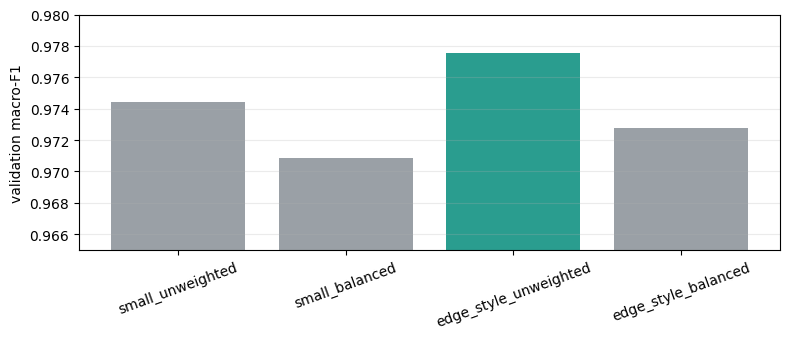

In [5]:
candidates = pd.read_csv(PROJECT_ROOT / "results_phase3" / "candidate_validation_comparison.csv")
candidate_view = candidates[[
    "candidate_id", "loss_policy", "best_epoch", "selected_threshold",
    "macro_f1", "attack_recall", "fpr", "selected",
]].copy()
display(candidate_view.round(4))

fig, axis = plt.subplots(figsize=(8, 3.5))
colors = ["#2a9d8f" if value else "#9aa0a6" for value in candidates["selected"]]
axis.bar(candidates["candidate_id"], candidates["macro_f1"], color=colors)
axis.set_ylim(0.965, 0.98)
axis.set_ylabel("validation macro-F1")
axis.tick_params(axis="x", rotation=20)
axis.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

The selected unweighted 128–64–32 model improved macro-F1 and reduced false
positives. Positive-class weighting slightly increased recall in one candidate,
but its higher FPR reduced the balanced macro-F1 objective.

## 6. Three fair training paths

- **Local-only:** each model sees one client partition and uses the common
  validation set for checkpoint/threshold selection.
- **Centralized:** the same initialization and optimizer see all pooled training
  rows.
- **FedAvg:** every round sends the same global state to all five clients; each
  trains for two epochs with reset optimizer state; sample counts weight updates.

In [6]:
central_history = pd.read_csv(PROJECT_ROOT / "results_phase3" / "centralized_training_history.csv")
local_history = pd.read_csv(PROJECT_ROOT / "results_phase3" / "local_only_training_history.csv")
federated_history = pd.read_csv(PROJECT_ROOT / "results_phase3" / "federated_round_history.csv")
central_checkpoint = torch.load(
    repo_path(lock["model_artifacts"]["centralized"]["path"]), map_location="cpu", weights_only=True
)

history_summary = pd.DataFrame([
    {
        "path": "centralized",
        "units": central_checkpoint["epochs_executed"],
        "selected_unit": central_checkpoint["best_epoch"],
        "unit_name": "epoch",
    },
    *[
        {
            "path": f"local/{client_id}",
            "units": lock["validation_metrics"][f"local/{client_id}"]["epochs_executed"],
            "selected_unit": lock["validation_metrics"][f"local/{client_id}"]["best_epoch"],
            "unit_name": "epoch",
        }
        for client_id, group in local_history.groupby("client_id")
    ],
    {
        "path": "federated_fedavg",
        "units": federated_checkpoint["rounds_executed"],
        "selected_unit": federated_checkpoint["best_round"],
        "unit_name": "round",
    },
])
display(history_summary)

,path,units,selected_unit,unit_name
0,centralized,60,52,epoch
1,local/uav-client-1,21,11,epoch
2,local/uav-client-2,60,54,epoch
3,local/uav-client-3,36,26,epoch
4,local/uav-client-4,60,52,epoch
5,local/uav-client-5,48,38,epoch
6,federated_fedavg,30,30,round


### A small FedAvg calculation

The production helper is demonstrated below on one scalar per client using the
real sample counts. The same operation is applied tensor-by-tensor to the MLP.

In [7]:
counts = distribution.loc[distribution["partition"].str.startswith("train/"), "rows"].astype(int).tolist()
toy_states = [OrderedDict(weight=torch.tensor([float(index)])) for index in range(1, 6)]
toy_average = fedavg(toy_states, counts)["weight"].item()
manual_average = np.average(np.arange(1, 6, dtype=float), weights=counts)

display(pd.DataFrame({"client": range(1, 6), "sample_count": counts, "toy_update": range(1, 6)}))
print(f"FedAvg helper: {toy_average:.6f}; independent weighted mean: {manual_average:.6f}")
assert np.isclose(toy_average, manual_average, atol=1e-7)

,client,sample_count,toy_update
0,1,1230,1
1,2,1046,2
2,3,591,3
3,4,2027,4
4,5,1254,5


FedAvg helper: 3.167372; independent weighted mean: 3.167372


## 7. Frozen validation comparison

Validation finalized the architecture, checkpoints, and thresholds. The final
test played no role in these choices.

In [8]:
validation = pd.read_csv(PROJECT_ROOT / "results_phase3" / "validation_model_comparison.csv")
metrics = ["model", "threshold", "accuracy", "macro_f1", "attack_precision", "attack_recall", "fpr"]
display(validation[metrics].round(4))

local_validation = validation[validation["model"].str.startswith("local/")]
print(f"Local mean macro-F1: {local_validation['macro_f1'].mean():.4f}")
print(f"Centralized – FedAvg macro-F1 gap: {validation.iloc[0]['macro_f1'] - validation.iloc[1]['macro_f1']:.4f}")

,model,threshold,accuracy,macro_f1,attack_precision,attack_recall,fpr
0,centralized,0.46,0.9842,0.9775,0.9928,0.9868,0.0246
1,federated_fedavg,0.42,0.9628,0.9467,0.9757,0.9762,0.0833
2,local/uav-client-1,0.28,0.9499,0.9266,0.9592,0.9769,0.1429
3,local/uav-client-2,0.49,0.9601,0.9420,0.9679,0.9811,0.1117
4,local/uav-client-3,0.90,0.9286,0.8905,0.9313,0.9801,0.2485
5,local/uav-client-4,0.48,0.9430,0.9208,0.9752,0.9506,0.0830
6,local/uav-client-5,0.22,0.8364,0.7926,0.9458,0.8368,0.1648


Local mean macro-F1: 0.8945
Centralized – FedAvg macro-F1 gap: 0.0308


## 8. Locked-test evaluation — reported separately

This cell reads the saved result table, not `test.csv`. Frozen thresholds and
checkpoints were applied once after the lock was written.

In [9]:
test_metrics = pd.read_csv(PROJECT_ROOT / "results_phase3" / "locked_test_model_metrics.csv")
display(test_metrics[
    ["model", "threshold", "accuracy", "macro_f1", "attack_precision", "attack_recall", "fpr", "tn", "fp", "fn", "tp"]
].round(4))

local_test = test_metrics[test_metrics["model"].str.startswith("local/")]
central = test_metrics.loc[test_metrics["model"].eq("centralized")].iloc[0]
fed = test_metrics.loc[test_metrics["model"].eq("federated_fedavg")].iloc[0]
print(f"FedAvg vs local mean macro-F1: {fed.macro_f1 - local_test.macro_f1.mean():+.4f}")
print(f"FedAvg vs centralized macro-F1: {fed.macro_f1 - central.macro_f1:+.4f}")

,model,threshold,accuracy,macro_f1,attack_precision,attack_recall,fpr,tn,fp,fn,tp
0,centralized,0.46,0.9841,0.9775,0.9923,0.9871,0.0260,11898,318,538,41195
1,federated_fedavg,0.42,0.9650,0.9502,0.9780,0.9767,0.0749,11301,915,971,40762
2,local/uav-client-1,0.28,0.9519,0.9295,0.9595,0.9791,0.1410,10493,1723,874,40859
3,local/uav-client-2,0.49,0.9618,0.9444,0.9680,0.9831,0.1111,10859,1357,704,41029
4,local/uav-client-3,0.90,0.9322,0.8977,0.9372,0.9778,0.2237,9483,2733,927,40806
5,local/uav-client-4,0.48,0.9462,0.9256,0.9786,0.9512,0.0711,11347,869,2036,39697
6,local/uav-client-5,0.22,0.8301,0.7872,0.9468,0.8268,0.1586,10279,1937,7227,34506


FedAvg vs local mean macro-F1: +0.0533
FedAvg vs centralized macro-F1: -0.0273


The result is mixed: federation improves on the average isolated client, but
centralized pooling remains stronger and has a much lower false-positive rate.
This demonstrates behavior for these fixed logical sources—not privacy,
network security, physical UAV deployment, or statistical superiority over
multiple datasets and seeds.

## 9. Client and attack-family weaknesses

Aggregate binary scores can hide calibration and family-level failures.

In [10]:
family = pd.read_csv(PROJECT_ROOT / "results_phase3" / "locked_test_original_class_detection.csv")
family_view = family[family["model"].isin(["centralized", "federated_fedavg"])].pivot(
    index="original_label", columns="model", values="predicted_attack_rate"
)
display(family_view.round(4))

worst_local = local_test.loc[local_test["macro_f1"].idxmin()]
best_local = local_test.loc[local_test["macro_f1"].idxmax()]
print(f"Best local: {best_local.model}, macro-F1={best_local.macro_f1:.4f}")
print(f"Worst local: {worst_local.model}, macro-F1={worst_local.macro_f1:.4f}, FN={int(worst_local.fn):,}")

model,centralized,federated_fedavg
original_label,,
Blackhole Attack,1.0000,0.9968
Flooding Attack,0.9958,0.9990
Normal Traffic,0.0260,0.0749
Sybil Attack,0.9997,0.9988
Wormhole Attack,0.9587,0.9264


Best local: local/uav-client-2, macro-F1=0.9444
Worst local: local/uav-client-5, macro-F1=0.7872, FN=7,227


Wormhole is the weakest attack family for centralized and FedAvg. Local
thresholds range from 0.22 to 0.90, and client 5 is substantially weaker on the
common held-out data—evidence of non-IID sensitivity and unstable calibration.

## 10. Reproducibility check

The project verifier checks the frozen lock, model/preprocessor hashes, saved
prediction columns, recomputed metrics, confusion counts, and plots without
opening the test partition.

In [11]:
import verify_phase3_artifacts

verify_phase3_artifacts.main()

Phase 3 verification passed: lock, 8 checkpoints/preprocessor artifacts, 3 result hashes, 7 saved prediction/metric pairs, and 8 plots.


## Phase 3 takeaway

Carry the exact feature order, fitted transformer, architecture, global
checkpoint, threshold, sample-weighted aggregation rule, and version/hash checks
forward. Keep calling the clients logical source groups and disclose that the
shared preprocessing statistics were fitted centrally.